**Boundary Extraction**

To extract object boundaries using morphological operations.

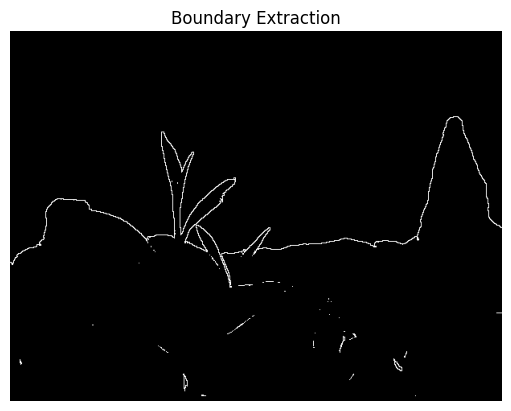

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/Test_2.jpg', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

kernel = np.ones((3,3), np.uint8)

eroded = cv2.erode(binary, kernel)
boundary = cv2.subtract(binary, eroded)

plt.imshow(boundary, cmap='gray')
plt.title("Boundary Extraction")
plt.axis('off')
plt.show()

**Region Filling**

To fill holes in a binary image using seed point and dilation.

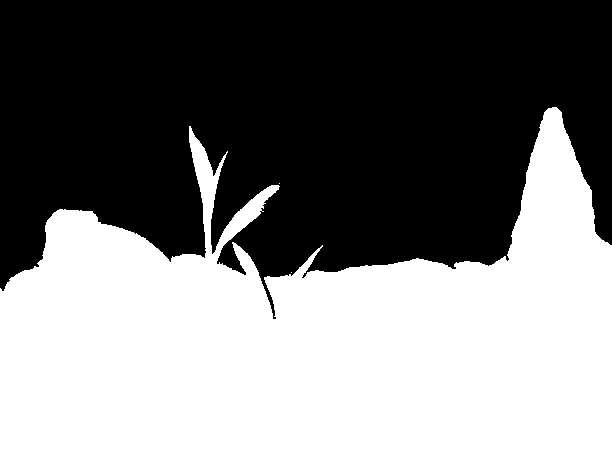

In [35]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Test_2.jpg', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

h, w = binary.shape
mask = np.zeros((h+2, w+2), np.uint8)

filled = binary.copy()
cv2.floodFill(filled, mask, (0,0), 255)

filled_inv = cv2.bitwise_not(filled)
result = binary | filled_inv

cv2_imshow(result)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Extraction of Connected Components**

To label and extract individual connected regions.

Number of components: 2


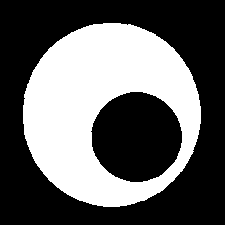

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Test_3.png', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

num_labels, labels = cv2.connectedComponents(binary)

print("Number of components:", num_labels)

# Display labeled image
label_img = np.uint8(255 * labels / np.max(labels))
cv2_imshow(label_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Convex Hull**

To compute convex hull of objects in an image.

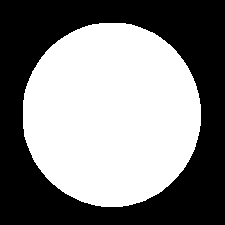

In [5]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Test_3.png', 0)
# Changed from '/content/sample_data'
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

hull_img = np.zeros_like(binary)

for cnt in contours:
    hull = cv2.convexHull(cnt)
    cv2.drawContours(hull_img, [hull], -1, 255, -1)

cv2_imshow(hull_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Thinning**

To perform thinning using morphological operations.

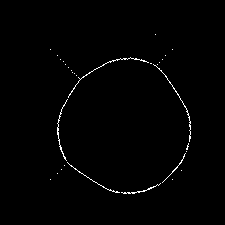

In [8]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Test_3.png', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

size = np.size(binary)
skeleton = np.zeros(binary.shape, np.uint8)

element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
done = False

while not done:
    eroded = cv2.erode(binary, element)
    temp = cv2.dilate(eroded, element)
    temp = cv2.subtract(binary, temp)
    skeleton = cv2.bitwise_or(skeleton, temp)
    binary = eroded.copy()

    if cv2.countNonZero(binary) == 0:
        done = True

cv2_imshow(skeleton)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Thickening**
To increase object thickness using morphological operations.

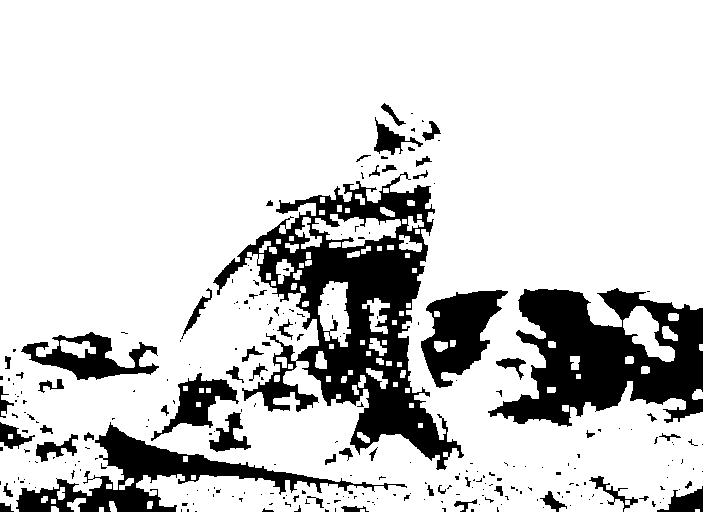

In [11]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Test_1.jpg', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

kernel = np.ones((3,3), np.uint8)

thick = cv2.dilate(binary, kernel, iterations=2)

cv2_imshow(thick)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Skeletons**

To extract skeletons from binary images.

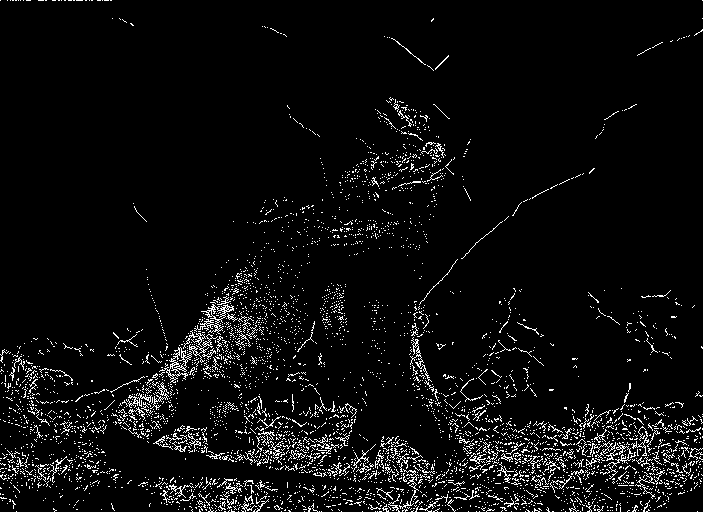

In [13]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Test_1.jpg', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

skeleton = np.zeros(binary.shape, np.uint8)
element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))

while True:
    eroded = cv2.erode(binary, element)
    temp = cv2.dilate(eroded, element)
    temp = cv2.subtract(binary, temp)
    skeleton = cv2.bitwise_or(skeleton, temp)
    binary = eroded.copy()

    if cv2.countNonZero(binary) == 0:
        break

cv2_imshow(skeleton)
cv2.waitKey(0)
cv2.destroyAllWindows()

**Pruning**

To eliminate noise and small branches from skeleton.

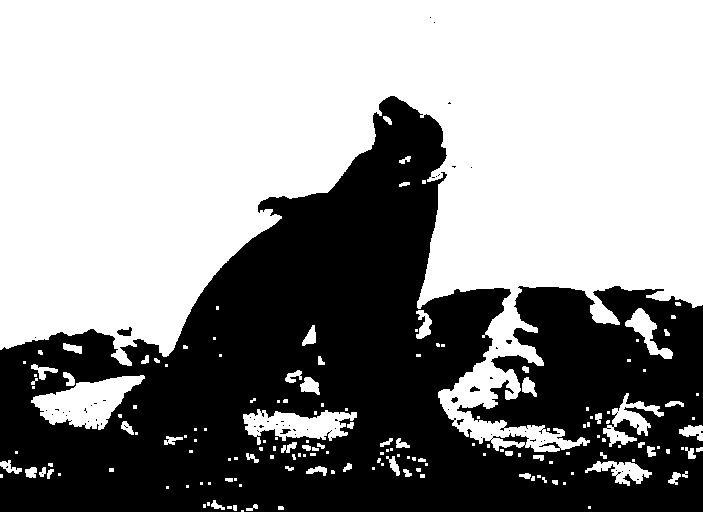

In [15]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Test_1.jpg', 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

kernel = np.ones((3,3), np.uint8)

# Perform opening to remove small branches
pruned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

cv2_imshow(pruned)
cv2.waitKey(0)
cv2.destroyAllWindows()